#Evidencia 1 // Jose Antonio Hernandez Chowell -- 2905562

* Sofía, analista de datos, recibe de manera mensual un conjunto de datos que incluye ingresos, gastos y utilidad por cliente. La alta dirección señala que, aunque se presentan numerosos gráficos, estos generan pocos insights accionables. Ante este escenario, Sofía debe explorar, diseñar y auditar visualizaciones con el propósito de transformar los datos disponibles en mensajes claros que faciliten la toma de decisiones.


Instrucciones

Deberás construir una evidencia que incluya:

* Un mínimo de tres visualizaciones, de las cuales al menos una deberá ser estática y una interactiva.
Al menos dos iteraciones de visualización (antes/después o versión A/B).
Una justificación escrita que incluya el objetivo de la visualización, la codificación elegida, la auditoría de errores detectados y una recomendación final.



* Importante. No existe una única respuesta correcta. La evaluación se centrará en la calidad del razonamiento, la coherencia entre el objetivo planteado, el tipo de gráfico seleccionado y la interpretación realizada, así como en la profundidad de la auditoría visual.

In [ ]:
import pandas as pd
import numpy as np

np.random.seed(7)

n_clientes = 40
clientes = [f"Cliente_{i:03d}" for i in range(1, n_clientes+1)]
categorias = ["A", "B", "C"]
fechas = pd.date_range("2025-01-01", periods=180, freq="D")

rows = []
for c in clientes:
    cat = np.random.choice(categorias)
    for f in fechas:
        ingresos = np.random.gamma(2.2, 220)
        gastos = ingresos * np.random.uniform(0.55, 0.92)
        utilidad = ingresos - gastos
        rows.append([f, c, cat, ingresos, gastos, utilidad])

df = pd.DataFrame(rows, columns=["fecha","cliente","categoria","ingresos","gastos","utilidad"])
df["margen_pct"] = np.where(df["ingresos"]>0, df["utilidad"]/df["ingresos"], 0)

df.head()


,fecha,cliente,categoria,ingresos,gastos,utilidad,margen_pct
0,2025-01-01,Cliente_001,A,321.641773,293.291019,28.350754,0.088144
1,2025-01-02,Cliente_001,A,1022.775321,752.163875,270.611447,0.264585
2,2025-01-03,Cliente_001,A,365.263709,292.691325,72.572384,0.198685
3,2025-01-04,Cliente_001,A,329.487054,227.658494,101.828561,0.309052
4,2025-01-05,Cliente_001,A,363.558542,228.661083,134.897459,0.371047


/tmp/ipython-input-1719581225.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




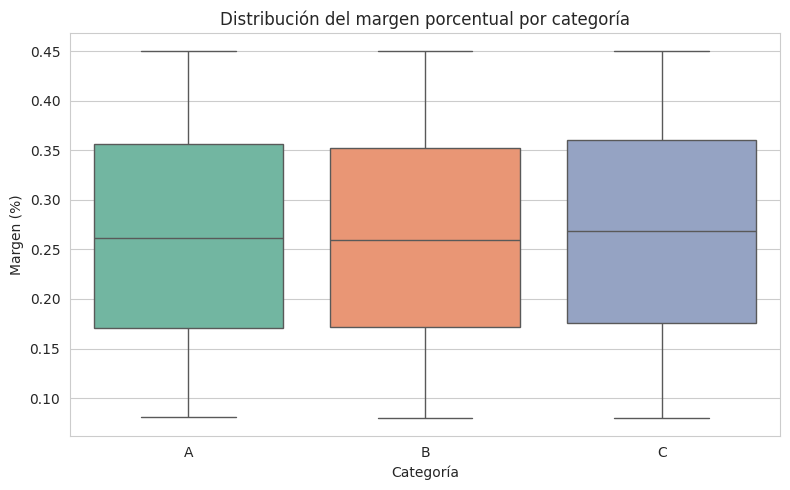

In [ ]:


sns.set_style("whitegrid")

plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x="categoria",
    y="margen_pct",
    palette="Set2"
)

plt.title("Distribución del margen porcentual por categoría")
plt.xlabel("Categoría")
plt.ylabel("Margen (%)")

plt.tight_layout()
plt.show()




#¿Qué variables corresponden a categorías y cuáles son cuantitativas o temporales?

Variables Categoricas:
*   Cliente: identifica a cada cliente
*   Catrgoria: clasifica a los clientes en grupos

Variable temporal:

*   Fecha: representa el tiempo en dias consecutivos; permite analisis de tendencias y evolucion

Variables cuantitativas

*   Ingresos: monto generado por cliente en cada fecha
*   gastos: costos asociados a los ingresos
   diferencia entre ingresos y gastos
*   utilidad: diferencia entre ingresos y gastos
*   margen_pct: proporcion de utilidad resepcto a ingresos









# ¿Que unidad o escala seria relevante agregar para mayor contexto?

*   Ingresos,gastos y utilidad se les deberia agregar una unidad monetaria
*   Fecha, indicar explicitamente el tiempo
*   margen_pct, aclarar que es porcentaje (%)


*   Elemento de lista



In [ ]:
df.describe(include="all").T

df.isna().sum()

df.groupby("categoria")[["ingresos","gastos","utilidad","margen_pct"]].mean().round(2)


,ingresos,gastos,utilidad,margen_pct
categoria,,,,
A,477.26,351.86,125.39,0.26
B,490.46,361.96,128.49,0.26
C,492.22,359.11,133.11,0.27


#¿Qué patrón inicial identifica Sofía a partir de la exploración?

*   Puede indentificar que usando df.describe y el groupby por categoria, sofia podria identificar que existen diferencias entre las categorias A , B Y C en terminos de ingresos,gastos y utilidad. En los ingresos sofia podria ver que son similares, pero en margen_pct varia, lo que sugiere que algunas catrgorias son mas eficientes en controlar costos.
Tambien sofia podra notar la ausencia de valores nulos donde se confirma que los resultados con consistentes y confiables para analisis estrategico




#¿Qué pregunta de negocio puede formularse con base en estos resultados?

*   ¿ Que categoria de clientes genera mayor rentabilidad y margen, deberia priorizarse para estrategias comerciales,asignacion de recursos?

En mi opinion esta pregunta permite usar graficos descriptivos e decisiones accionables enfocadas en optimizacion de portafolio de clientes



#Definir objetivo: explorar frente a explicar. Instrucción: definir dos objetivos claramente diferenciados:

A. **Un objetivo exploratorio orientado al descubrimiento de patrones**: Explorar el comportamiento de los ingresos,gastos,utilidad y margen por cliente, categoria y tiempo, para poder indentificar patrones, tendencias y relaciones no evidentes, como por ejemplo clientes que concentran mayor utilidad.
para asi poder respaldar desiciones estrategicas de enfoque comercial





B. **Un objetivo explicativo enfocado en la comunicación de un mensaje específico.**: Para poder explicar de manera clara y directa que categoria y que clientes dominan la generacion de utilidad , evidenciando si mayores ingresos se traducen o no en mejores margenes,para poder tener decsiones estrategicas de enfoque comercial.

#Visualización A/B: misma información, dos codificaciones. Se deberán desarrollar dos versiones de la visualización utilizando Matplotlib o Seaborn, manteniendo la misma información, pero modificando la codificación visual.

/tmp/ipython-input-4257891681.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_m = df.set_index("fecha").resample("M")[["ingresos","gastos","utilidad"]].sum().reset_index()


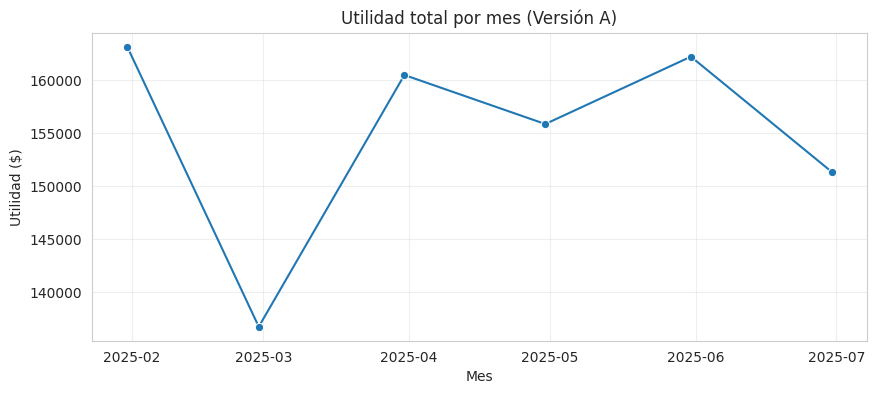

In [ ]:

#Código versión A

import matplotlib.pyplot as plt
import seaborn as sns

# Agregación mensual
df_m = df.set_index("fecha").resample("M")[["ingresos","gastos","utilidad"]].sum().reset_index()

plt.figure(figsize=(10,4))
sns.lineplot(data=df_m, x="fecha", y="utilidad", marker="o")
plt.title("Utilidad total por mes (Versión A)")
plt.xlabel("Mes")
plt.ylabel("Utilidad ($)")
plt.grid(True, alpha=0.3)
plt.show()

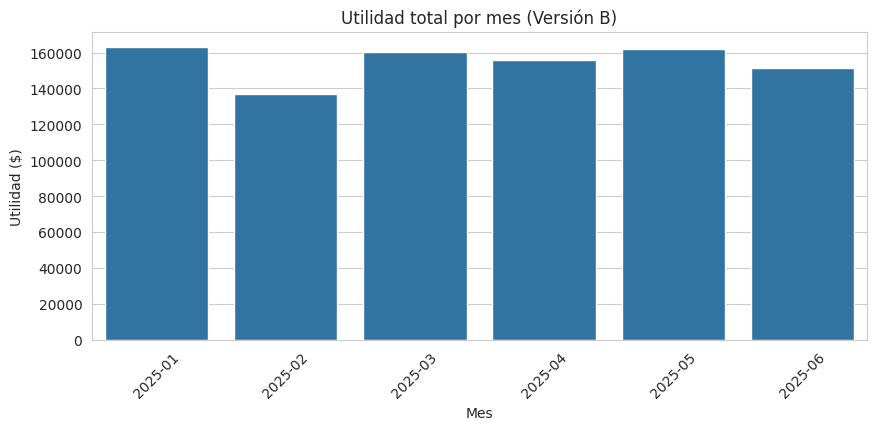

In [ ]:
#Código versión B

plt.figure(figsize=(10,4))
sns.barplot(data=df_m, x=df_m["fecha"].dt.strftime("%Y-%m"), y="utilidad")
plt.title("Utilidad total por mes (Versión B)")
plt.xlabel("Mes")
plt.ylabel("Utilidad ($)")
plt.xticks(rotation=45)
plt.show()


#¿Cuál versión presenta una menor carga cognitiva para la comparación?

* En mi opinion la version B presenta una menor carga cognitiva para la comparacion, ya que la longitud de las barras nos permite comparar de forma directa la magnitud de la utilidad entre meses.

#¿Cuál versión facilita mejor la identificación de tendencias?

* En mi opinion la version A en este caso facilita la mejor identificacion de tendencias,debido a la conexion entre puntos enfatiza la evolucion temporal y permite detectar patrones de crecimiento, disminucion o estabilidad

#¿Qué canal visual se utiliza como principal (posición, longitud o color)?

* En este caso en ambas visualizaciones, el canal visual principal es la posicion sobre los ejes, en la version B se utiliza longitud de las barras como canal dominante para representar la magnitud de la utilidad

#Gráfico como argumento. Se deberá elaborar un gráfico que incorpore contexto y anotaciones relevantes.


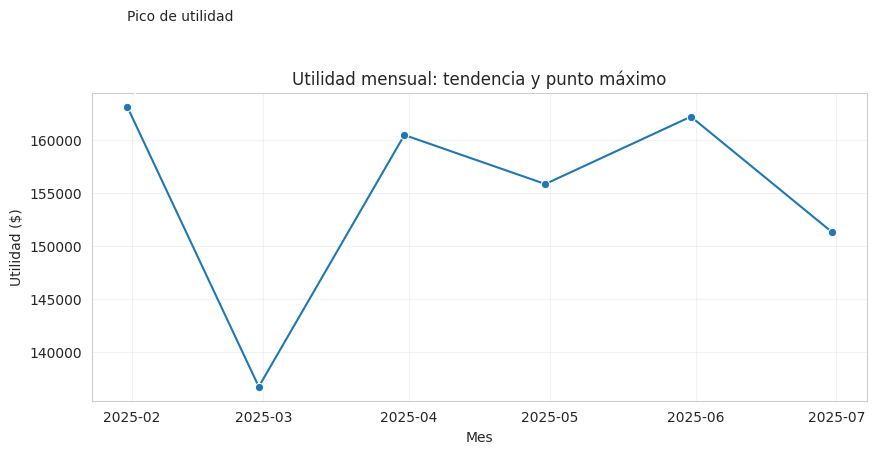

In [ ]:

# Seleccionar mes con máxima utilidad para anotarlo
max_idx = df_m["utilidad"].idxmax()
max_row = df_m.loc[max_idx]

plt.figure(figsize=(10,4))
sns.lineplot(data=df_m, x="fecha", y="utilidad", marker="o")
plt.title("Utilidad mensual: tendencia y punto máximo")
plt.xlabel("Mes")
plt.ylabel("Utilidad ($)")
plt.grid(True, alpha=0.25)

plt.annotate(
    "Pico de utilidad",
    xy=(max_row["fecha"], max_row["utilidad"]),
    xytext=(max_row["fecha"], max_row["utilidad"]*1.05),
    arrowprops=dict(arrowstyle="->")
)

plt.show()


#¿Qué mensaje comunica el título del gráfico?

* El titulo nos comunica que la vizualicacion buscca mostrar como evoluciona la utilidad a o argo del tiempo y resaltar explicitamente el mes con mayor utilidad.




#¿Qué decisión podría derivarse de la información presentada?

* Los directivos podrian analizar que factores operativos o comerciale ocurrieron en el mes de pico de utilidad para replicar esas condiciones en otros periodos, o bien planificar estrategias considerando meses de alto y bajo desempeño



#¿Qué información adicional sería necesaria (unidades, periodo, fuente o notas)?


*   Periodo exacto (Año o rango de fechas)
*   Unidad monetaria (USD O MXN)
*   Notas sobre posibles causas del pico



#Interactividad — Plotly Express. Se desarrollará una visualización interactiva que permita explorar la información por categoría.

In [ ]:
import plotly.express as px

df_cat_m = (
    df.set_index("fecha")
      .groupby("categoria")
      .resample("M")[["utilidad"]]
      .sum()
      .reset_index()
)

fig = px.line(
    df_cat_m, x="fecha", y="utilidad", color="categoria",
    markers=True,
    title="Utilidad mensual por categoría (interactivo)"
)
fig.show()



/tmp/ipython-input-2592303844.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")[["utilidad"]]


¿Qué valor aporta la funcionalidad hover al análisis?

* La funcionalidad hover nos permite acceder a los  valores exactos de utilidad  por mes y categoria sin saturar el grafico con etiquetas. Eso nos facilita las comparaciones precisas,deteccion de picos o caidas especificas y un analisis exploratorio mas profundo

¿Qué riesgos presenta el uso de visualizaciones interactivas en términos de rendimiento o impresión de reportes?

* Las visualizaciones interactivas pueden presentar problemas de rendimiento congrandes volumenes de datos,generando tiempos de carga elevados.
Cuando se exporta las graficas interactivas se pierde la interactividad, lo que reduce el mensaje por la falta de claridad.

#Auditoría visual — checklist y correcciones. Instrucción: seleccionar una visualización previamente creada y evaluarla mediante el siguiente checklist:
se escogio la visualizacion interactiva

"Utilidad mensual por categoria"

* ¿Existe algún eje truncado sin advertencia explícita?
No, El eje Y comienza en un valor normal con los datos y no tiene problemas, por lo que se podria decir que no las diferencias entre categorias son reales

* ¿Se emplea tridimensionalidad innecesaria?
No, La visualizacion es bidimensional, lo cual es adecuado y asi se evitan distorsiones



* ¿Hay elementos de chartjunk que distraigan del mensaje principal?
No ,nada de elementos como sombras , efectos decorativos ni elementos graficos innecesarios.


* ¿La paleta de color puede inducir a interpretaciones erróneas?
No, los colores distinguen categorias sin jerarquizarlas, pero si podriamos mejorar el grafico usand una paleta apta para daltonicos.


* ¿El título comunica un mensaje o únicamente describe el tipo de gráfico?  
Solamente describe el grafico, entonces mi conlusion si podria mejorarse para comunicar mejor en el titulo


* ¿Se indican claramente las unidades, el periodo y las notas relevantes?
Parcialmente, El periodo se infiere por el eje temporal, pero seria mejor especificar explicitamente las unidades monetarias, rango de fechas.




#Conclusión accionable. Sofía deberá cerrar la evidencia con una recomendación fundamentada, respondiendo a las siguientes preguntas:

¿Qué visualización se presentaría a la dirección y por qué?


*   Se presentaria la visualizacion interactiva de utilidad mensual por categoria, la razon seria que nos permite comparar categorias rapidamente y por la interactividad, facilitia  responder preguntas estrategicas sin sobrecargar  con muchos detalles tecnicos



¿Qué visualización sería más adecuada para el análisis interno y por qué?

*   Las visualizciones estaticas A/B de utilidad mensual son las mas adecuadas para el analisis interno, ya que reducen la carga visual, pero si permiten detectar tendencias con claridad y facilitan comparaciones consistentes.


¿Qué decisión concreta se habilita a partir del análisis realizado?

* El analisis permite que podamos priorizar la categoria con mayor y mas estable utilidad, podriamos ajustar estrategias para meses de baja rentabilidad y enfocar acciones comercilaes o algun control de gastos